# Financial Data Labeling

## Overview

This notebook demonstrates the public functions in `financial_data_labeling` using dollar bars built from a raw Alpaca trade file.
- The notebook estimates daily volatility from a dollar-bar close series.
- It builds triple-barrier events from CUSUM timestamps, fixed vertical barriers, and a simple side signal.
- It converts event outcomes into labels and filters rare classes.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from src.data_preprocessing.financial_data_labeling import (
    apply_profit_taking_stop_loss_on_t1,
    drop_labels,
    get_bins,
    get_daily_volatility,
    get_events,
    get_vertical_barriers,
)
from src.data_preprocessing.financial_data_structures import get_cusum_events, get_dollar_bars

## Load raw Alpaca trades

This section reads the same AAPL trade file used by the other preprocessing notebooks and resamples it into dollar bars.
- The transformed feature input is the dollar-bar close series.
- The notebook keeps the input as a one-dimensional close series because the labeling functions operate on timestamped prices.
- The dollar-bar threshold is derived from `target_bars_per_day = 24` and the number of distinct trading dates in the raw trade sample.
- Using the same raw source file keeps the examples aligned across notebooks.


In [3]:
data_path = Path("data/raw/alpaca/stock_aapl_trades_20260101T000000Z_20260131T000000Z.parquet")
alpaca_path = next(
    (path / data_path for path in [Path.cwd(), *Path.cwd().parents] if (path / data_path).exists()),
    data_path,
)

trades = pd.read_parquet(alpaca_path).sort_values("timestamp").reset_index(drop=True)[["timestamp", "symbol", "price", "size"]].copy()
notional = trades["price"].astype(float) * trades["size"].astype(float)
target_bars_per_day = 24
trading_days = trades["timestamp"].dt.normalize().nunique()
target_num_bars = max(1, trading_days * target_bars_per_day)
dollar_threshold = float(notional.sum() / target_num_bars)
dollar_bars = get_dollar_bars(trades, threshold=dollar_threshold).ohlcv
dollar_close = dollar_bars["close"].astype(float)

print(f"source: {alpaca_path}")
print(f"trading_days: {trading_days}")
print(f"target_bars_per_day: {target_bars_per_day}")
print(f"num_dollar_bars: {len(dollar_close):,}")
dollar_close.head()

source: /Users/kwonjunhyuk9/Documents/financial-machine-learning/data/raw/alpaca/stock_aapl_trades_20260101T000000Z_20260131T000000Z.parquet
trading_days: 20
target_bars_per_day: 24
num_dollar_bars: 479


end
2026-01-02 14:41:10.943383+00:00    274.28
2026-01-02 14:48:49.651065+00:00    277.18
2026-01-02 15:00:22.257127+00:00    277.11
2026-01-02 15:14:20.199050+00:00    275.72
2026-01-02 15:30:31.439947+00:00    273.23
Name: close, dtype: float64

### Interpretation

This run builds a compact but still information-rich dollar-bar close series for the labeling pipeline.
- The raw AAPL sample covers 20 trading days and is compressed into 479 dollar bars, so the later labeling steps work on a denser event-time series than daily data.
- `target_bars_per_day = 24` is not just a styling choice here; it is the reason the notebook lands near a few hundred bars instead of a handful of calendar observations.
- `dollar_close` is the only price input used below, so every volatility estimate, event boundary, and label in this notebook is anchored to this resampled path rather than to raw trades.


## Estimate Daily Volatility

This section applies `get_daily_volatility` to the dollar-bar close series.
- The function compares each close with the close from one calendar day earlier.
- The exponentially weighted standard deviation makes the volatility estimate adaptive.
- That volatility estimate becomes the target return series for triple-barrier events.

end
2026-01-05 14:38:12.736933+00:00    0.004776
2026-01-05 14:47:25.900839+00:00    0.003825
2026-01-05 15:04:53.431266+00:00    0.003467
2026-01-05 15:23:07.991016+00:00    0.002999
2026-01-05 15:36:46.219396+00:00    0.002668
dtype: float64

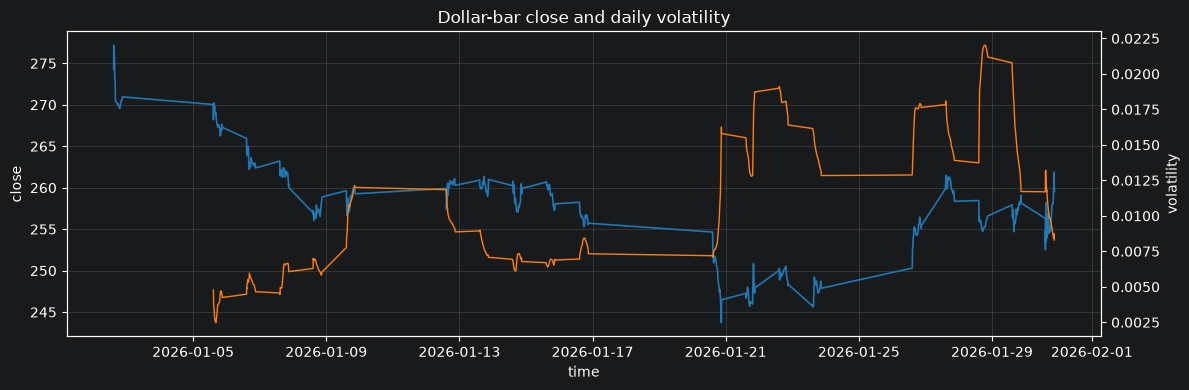

In [4]:
daily_volatility = get_daily_volatility(dollar_close, span0=50)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dollar_close.index, dollar_close, label="Dollar-bar close", color="tab:blue", linewidth=1.2)
ax2 = ax.twinx()
ax2.plot(daily_volatility.index, daily_volatility, label="Daily volatility", color="tab:orange", linewidth=1.0)
ax.set_title("Dollar-bar close and daily volatility")
ax.set_xlabel("time")
ax.set_ylabel("close")
ax2.set_ylabel("volatility")
ax.grid(alpha=0.25)
fig.tight_layout()

daily_volatility.dropna().head()

### Interpretation

The volatility estimate starts only once the notebook has enough history to compare each bar with a bar from one calendar day earlier.
- In this run the first non-null estimate appears at `2026-01-05 14:38:12+00:00`, with a volatility of about `0.0048`, so the early bars are still warming up the one-day lookback.
- The orange series should be read as a local barrier width: when it rises, later triple barriers become wider because `trgt` is larger; when it falls, the event targets tighten.
- Because the estimate is exponentially weighted, the recent part of the path matters more than the distant past, which is why the line reacts smoothly instead of jumping bar by bar.


## Build Triple-Barrier Events

This section uses `get_events` to combine CUSUM timestamps, volatility targets, vertical barriers, and a simple side signal.

Key points:
- `get_cusum_events` defines candidate event start times.
- `get_vertical_barriers` places the vertical barrier ten dollar bars after each eligible event start.
- The side signal is the sign of the five-bar return, which turns the example into a simple meta-labeling setup.
- The event visualization below shows where starts occur and how far each vertical barrier extends into the future.


In [5]:
cusum_threshold = float(dollar_close.diff().abs().median() * 2)
t_events = pd.DatetimeIndex(get_cusum_events(dollar_close, threshold=cusum_threshold))
t1 = get_vertical_barriers(t_events, dollar_close, numBars=10)
targets = daily_volatility.reindex(t_events)
side = dollar_close.pct_change(5).reindex(t_events).apply(lambda value: 1.0 if value >= 0 else -1.0)

eligible_events = targets.dropna().index.intersection(side.dropna().index).intersection(t1.index)
min_return = float(targets.loc[eligible_events].quantile(0.25))

events = get_events(
    close=dollar_close,
    tEvents=eligible_events,
    ptSl=[1.0, 1.0],
    trgt=targets,
    minRet=min_return,
    numThreads=1,
    t1=t1,
    side=side,
)

events.head()


,t1,trgt,side
2026-01-08 15:02:12.885445+00:00,2026-01-08 16:51:17.894626+00:00,0.006969,-1.0
2026-01-09 14:30:25.284783+00:00,2026-01-09 14:53:16.620733+00:00,0.007767,1.0
2026-01-09 14:40:40.647607+00:00,2026-01-09 18:01:14.328404+00:00,0.008532,1.0
2026-01-09 14:53:16.620733+00:00,2026-01-09 17:29:14.661978+00:00,0.008670,-1.0
2026-01-09 15:23:03.111729+00:00,2026-01-09 19:55:46.217912+00:00,0.009644,-1.0


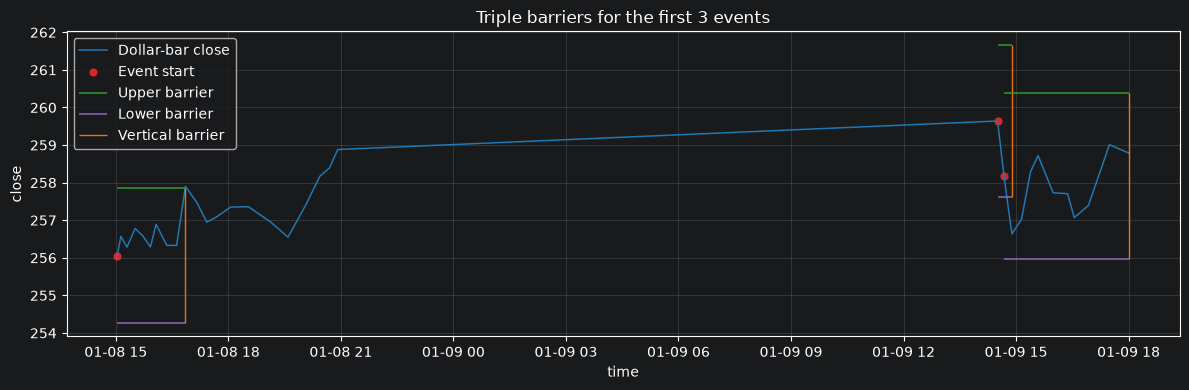

In [6]:
plot_events = events.head(3)
window_start = plot_events.index.min()
window_end = plot_events["t1"].max()
plot_close = dollar_close.loc[window_start:window_end]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_close.index, plot_close, color="tab:blue", linewidth=1.1, label="Dollar-bar close")
ax.scatter(plot_events.index, dollar_close.reindex(plot_events.index), color="tab:red", s=24, label="Event start")

for idx, (event_time, event_row) in enumerate(plot_events.iterrows()):
    event_price = dollar_close.loc[event_time]
    upper_barrier = event_price * (1 + event_row["trgt"])
    lower_barrier = event_price * (1 - event_row["trgt"])
    barrier_time = event_row["t1"]
    line_label_upper = "Upper barrier" if idx == 0 else None
    line_label_lower = "Lower barrier" if idx == 0 else None
    line_label_vertical = "Vertical barrier" if idx == 0 else None
    ax.hlines(upper_barrier, event_time, barrier_time, color="tab:green", linewidth=1.2, alpha=0.9, label=line_label_upper)
    ax.hlines(lower_barrier, event_time, barrier_time, color="tab:purple", linewidth=1.2, alpha=0.9, label=line_label_lower)
    ax.vlines(barrier_time, lower_barrier, upper_barrier, color="tab:orange", linewidth=1.0, alpha=0.9, label=line_label_vertical)

ax.set_title("Triple barriers for the first 3 events")
ax.set_xlabel("time")
ax.set_ylabel("close")
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()


### Interpretation

This stage shrinks hundreds of price bars into a smaller set of event windows that are actually worth labeling.
- The CUSUM filter finds 160 candidate starts, and 148 of them survive the combined `targets`, `side`, and `t1` checks, so only a small fraction of the 479 bars become labeled events.
- The first few surviving events have targets around `0.0070` to `0.0096`, which means the plotted upper and lower barriers are roughly `0.7%` to `1.0%` away from each event start price.
- In the 5-event plot, each red marker is an accepted start, each green and purple segment is the horizontal barrier pair implied by that event's own `trgt`, and each orange line marks the event's final `t1` cutoff.


## Label Event Outcomes

This section locates barrier hits, converts them into returns and bins, and drops underrepresented labels.

Key points:
- `apply_profit_taking_stop_loss_on_t1` finds the first horizontal barrier touched before the vertical barrier.
- `get_bins` turns each finished event into a realized return and a discrete label.
- `drop_labels` removes classes that are too rare for a stable classification target.
- The intermediate outputs are shown separately so you can inspect each function before looking at the final label frequencies.


In [7]:
barrier_hits = apply_profit_taking_stop_loss_on_t1(dollar_close, events, ptSl=[1.0, 1.0], molecule=events.index)
barrier_hits.head()

,t1,sl,pt
2026-01-08 15:02:12.885445+00:00,2026-01-08 16:51:17.894626+00:00,2026-01-08 16:51:17.894626+00:00,NaT
2026-01-09 14:30:25.284783+00:00,2026-01-09 14:53:16.620733+00:00,2026-01-09 14:53:16.620733+00:00,NaT
2026-01-09 14:40:40.647607+00:00,2026-01-09 18:01:14.328404+00:00,NaT,NaT
2026-01-09 14:53:16.620733+00:00,2026-01-09 17:29:14.661978+00:00,2026-01-09 17:29:14.661978+00:00,NaT
2026-01-09 15:23:03.111729+00:00,2026-01-09 19:55:46.217912+00:00,NaT,NaT


In [8]:
labeled_events = events.copy()
labeled_events["t1"] = barrier_hits.apply(
    lambda row: min([value for value in row if pd.notna(value)]) if any(pd.notna(row)) else pd.NaT,
    axis=1,
).fillna(events["t1"])
bins = get_bins(labeled_events, dollar_close)
bins.head()

,ret,bin
2026-01-08 15:02:12.885445+00:00,-0.007186,0.0
2026-01-09 14:30:25.284783+00:00,-0.011574,0.0
2026-01-09 14:40:40.647607+00:00,0.002363,1.0
2026-01-09 14:53:16.620733+00:00,-0.009254,0.0
2026-01-09 15:23:03.111729+00:00,-0.006349,0.0


In [9]:
filtered_bins = drop_labels(bins.copy(), minPct=0.10)

label_summary = pd.concat(
    {
        "raw_label_frequency": bins["bin"].value_counts(normalize=True).sort_index(),
        "filtered_label_frequency": filtered_bins["bin"].value_counts(normalize=True).sort_index(),
    },
    axis=1,
)

label_summary

,raw_label_frequency,filtered_label_frequency
bin,,
0.0,0.522523,0.522523
1.0,0.477477,0.477477


### Interpretation

The last three outputs show the same events at three different levels of resolution: barrier hits, realized returns, and class balance.
- In `barrier_hits.head()`, the first five rows contain three stop-loss hits and zero profit-taking hits, with `NaT` marking barriers that were never touched before the event ended.
- In `bins.head()`, the first five side-adjusted returns are about `-0.72%`, `-1.16%`, `+0.24%`, `-0.93%`, and `-0.63%`, so only the third event is labeled `1` and the other four become `0`.
- `label_summary` shows that the full sample is already fairly balanced at roughly `52.3%` label `0` versus `47.7%` label `1`, so `drop_labels` does not change the distribution in this run.
